# Image Segmentation Basic

* segmentation: 모든 픽셀에 대해 각 픽셀이 어떤 카테고리에 속하는지 분류하는 문제
* segmentation을 위한 neural network 직접 구현
* tensorflow, keras 사용

In [2]:
import os

In [3]:
os.environ['CUDA_VISIBLE_DEVICES'] = '6'

import tensorflow as tf
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

I0000 00:00:1785121715.073035 1926186 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785121715.077562 1926186 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785121715.435405 1926186 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 AMX_FP16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785121722.813505 1926186 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To t

### 1. Data

Oxford-IIIT Pet Dataset

* class1: Pixel belonging to the pet
* class2: Pixel bordering the pet
* class3: None of the above/ Surrounding pixel

In [4]:
import tensorflow_datasets as tfds
tfds.disable_progress_bar()

dataset, info = tfds.load('oxford_iiit_pet:4.*.*', with_info=True)

E0000 00:00:1785121735.377654 1926186 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1785121735.706831 1926186 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
info

tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/home/jovyan/aicon-gamma-datavol-1/hjgoh/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
        'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
        'image': Image(shape=(None, None, 3), dtyp

In [6]:
print('# of training sampels:', info.splits['train'].num_examples)
print('# of validation sampels:', info.splits['test'].num_examples)

# of training sampels: 3680
# of validation sampels: 3669


#### 1.1 Dataset preprocessing

* imgsz: 128*128
* normalize: 이미지를 0과 1 사이의 실수값, segmentation label을 0~2의 정수값
* load_image_train: data augmentation, random 반전
* load_image_test: resizing, normalization only 

In [7]:
def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask -= 1
    return input_image, input_mask

In [8]:
@tf.function
def load_image_train(datapoint):
    #resize 
    input_image = tf.image.resize(datapoint['image'], (128, 128))
    input_mask = tf.image.resize(datapoint['segmentation_mask'], (128, 128))

    # augmentation
    if tf.random.uniform(()) > 0.5:
        input_image = tf.image.flip_left_right(input_image)
        input_mask = tf.image.flip_left_right(input_mask)

    # normalize
    input_image, input_mask = normalize(input_image, input_mask)

    return input_image, input_mask 

In [9]:
def load_image_test(datapoint):
    # image, mask resize
    input_image = tf.image.resize(datapoint['image'], (128, 128))
    input_mask = tf.image.resize(datapoint['segmentation_mask'], (128, 128))
    
    # normalize
    input_image, input_mask = normalize(input_image, input_mask)

    return input_image, input_mask

#### 1.2 Data pipeline

tf.data의 batch 구성하기

* dataset['train'], ['test']는 tf.data 모듈에 정의한 tf.data.Dataset!
* tf.data의 API를 이용해 batch를 효율적으로 구성
* map: dataset에 있는 각 data point 하나마다 함수를 적용
* shuffle: BUFFER_SIZE 만큼의 데이터를 buffer에 넣고 셔플
* batch: BATCH_SIZE 만큼의 데이터를 하나의 batch로 묶어줌
* repeat: 해당 데이터셋을 이용할 때, 끝나지 않고 계속해서 batch 구성


In [10]:
TRAIN_LENGTH = info.splits['train'].num_examples
BATCH_SIZE = 64
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

In [11]:
train = dataset['train'].map(load_image_train, num_parallel_calls=tf.data.experimental.AUTOTUNE)
test = dataset['test'].map(load_image_test)

In [12]:
train_dataset = train.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()
test_dataset = test.batch(BATCH_SIZE)

#### 1.3 Data Display

* display: image / ground-truth segmentation mask / predicted mask를 보여주는 함수
* take(n): 데이터셋에서 n개의 데이터를 가져오는 함수

In [13]:
def display(display_list):
    plt.figure(figsize=(20, 20))
    title = ['Input Image', 'True Mask', 'Predicted Mask']

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

I0000 00:00:1785121757.778477 1928070 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


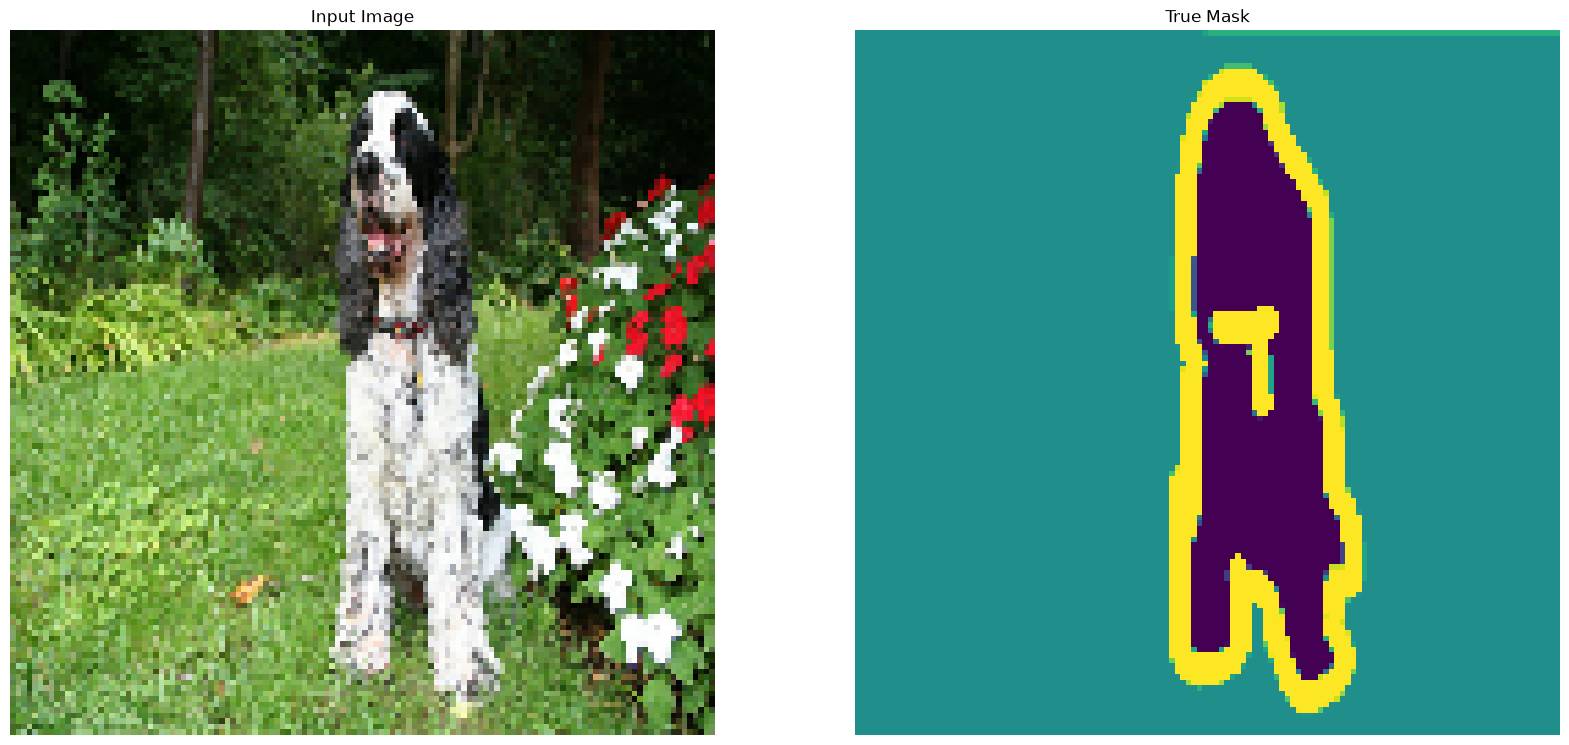

In [14]:
for image, mask in train.take(2):
    sample_image, sample_mask = image, mask
display([sample_image, sample_mask])

### 2. Model Design

* 픽셀 별 prediction
* neural network가 실수(128 x 128 x3)의 RGB 이미지를 입력으로 받고, (128 x 128 x C) 형태의 값을 출력
* C는 카테고리의 수고, 출력의 값은 픽셀의 (i, j)에 대해서 category별 점수로 표현. argmax 함수로 최종 segmentation mask를 assign 가능

In [15]:
OUTPUT_CHANNELS = 3

#### 2.1 Backbone Architecture: MobileNetV2

* pretrained mobilenetv2를 사용
* tf.keras.applications에 정의된 모델
* 모든 layer가 convolution으로 구성된 FCN을 사용
* ImageNet classification dataset에서 pre-trained 된 파라미터를 가지고 와서 fine-tuning!

In [16]:
backbone = tf.keras.applications.MobileNetV2(input_shape=[128, 128, 3], include_top=False)

layer_names = [
    'block_1_expand_relu',  # 84*84
    'block_3_expand_relu',  # 32*32
    'block_6_expand_relu',  # 16*16
    'block_13_expand_relu', # 8*8
    'block_16_project',     # 4*4
]

layers = [backbone.get_layer(name).output for name in layer_names]

backbone_features = tf.keras.Model(inputs=backbone.input, outputs=layers)
backbone_features.trainable = False

#### 2.2 Segmentation Module Implementation

* backbone architecture가 주어졌을 때 segmentation module을 구현하기
* Keras 사용
* tf.Keras.Model: input-output tensor를 지정하면 그 사이에 연결된 레이어를 묶고, 학습에 필요한 fit, complie 등의 메서드 사용 가능
* tf.Keras.Sequential: layer 하나로 묶어주기
* tf.Keras.layers.Conv2D: conv layer 하나 추가
* tf.Keras.layers.UpSampling2D: 이미지 형태의 input upsampling

In [30]:
# CNN head
def build_example_model():
    # input shape
    inputs = tf.keras.layers.Input(shape=[128, 128, 3])

    # feature
    features = backbone_features(inputs)

    # 사용할 feature map 정하기
    # 4번쨰 feature map은 8*8 resolution
    x = features[3]

    # feature map 기반 8*8 segmentation prediction mask를 만드는 CNN 생성
    # pretrained 모델이 뽑은 특징을 픽셀별 클래스 점수로 변환 / head의 역할!
    convnet = tf.keras.Sequential(layers = [
        tf.keras.layers.Conv2D(16, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2D(OUTPUT_CHANNELS, 3, padding='same'), 
        # 8*8 grid를 logit 벡터로 변환, 즉, 점수로 변환
        # 여기에서 softmax를 취해주면 픽셀별 클래스 확률! 
    ])
    x = convnet(x)

    # 8*8 출력값을 bilinear interpolation으로 128*128 업샘플 
    upsample = tf.keras.layers.UpSampling2D(
        size = (16, 16),
        interpolation = 'bilinear'
    )
    x = upsample(x)

    # x를 최종 출력값으로 갖는 모델을 만들기
    # 최종 상태: 확률이 되기 전의 logit, 입 출력의 크기 맞춤
    return tf.keras.Model(inputs=inputs, outputs=x)
    

### 3. Training

#### 3.1 Compile

* 정의한 함수로 모델을 실제로 만들고 컴파일
* compile: tf.keras.Model을 학습할 때 사용할 optimizer, loss, evaluation에 사용할 metrix 설저정
* optimizer: adam
* loss: losses.SparseCategoricalCrossentropy(fron_logits=True) / category에 해당하는 채널의 값이 높아지도록 학습

* visualization function
* create_mask: 모델 출력값으로 segmentation mask 만드는 함수
* show_predictions: model 이용해서 prediction + visualization
* tf.keras.utils.plot_model: 모델 구조 visulaization / input, output shape 확인해서 모델이 잘 정의됐는지 확인

In [18]:
model = build_example_model()
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [20]:
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]


def show_predictions(dataset=None, num=1):
    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = model.predict(image)
            display([image[0], mask[0], create_mask(pred_mask)])

    else: 
        display([sample_image, sample_mask, create_mask(model.predict(sample_image[tf.newaxis, ...]))])

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


#### 3.2 Training

* model.fit으로 모델 학습
* on_epoch_end: 학습마다 training epoch이 끝날 때마다 호출
* clear_output 함수를 이용해서 이전에 띄운 결과를 지우고 새로운 결과를 visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step


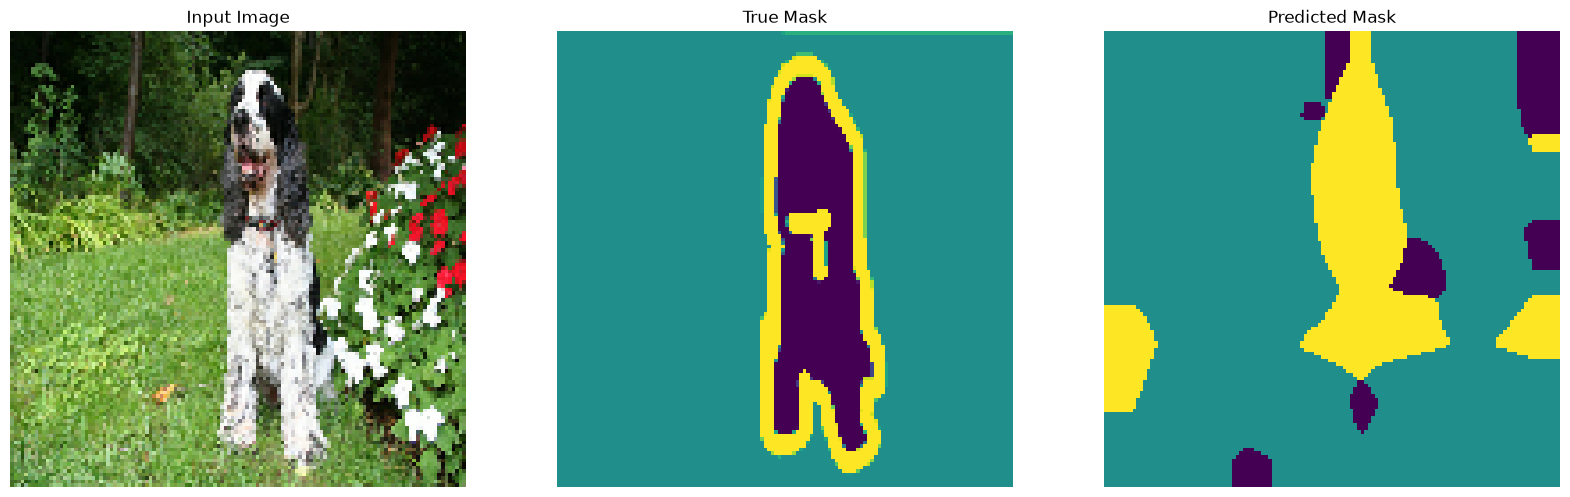

In [22]:
show_predictions()

In [23]:
class DisplayCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        clear_output(wait=True)
        show_predictions()
        print('\nSample Prediction after epoch{}\n'.format(epoch+1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


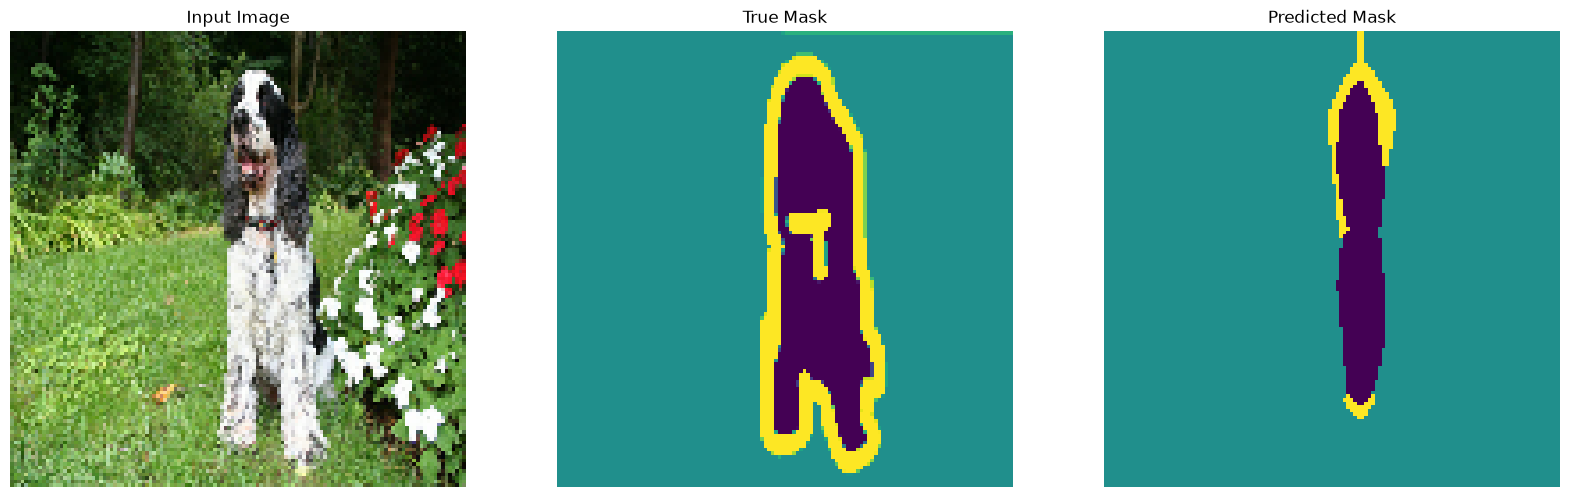


Sample Prediction after epoch10

57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 316ms/step - accuracy: 0.8660 - loss: 0.3029 - val_accuracy: 0.8635 - val_loss: 0.3037


In [25]:
EPOCHS = 10 
VAL_SUBSPLITS = 10
VALIDATION_STEPS = info.splits['test'].num_examples//BATCH_SIZE//VAL_SUBSPLITS

model_history = model.fit(
    train_dataset, 
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=test_dataset,
    callbacks=[DisplayCallback()],
)

### 4. Evaluation

* 정량 평가
* training loss, validation loss 확인
* picel accuracy 확인

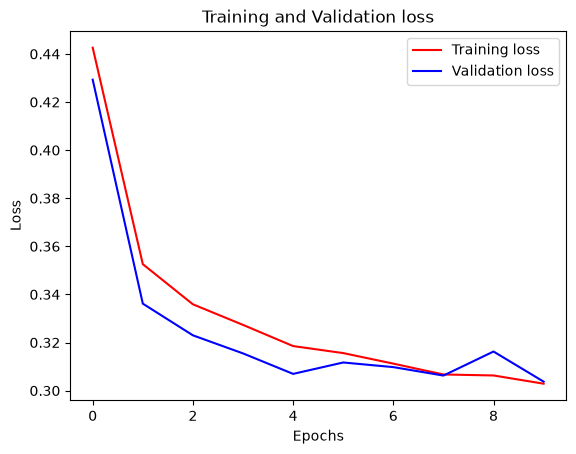

In [27]:
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(EPOCHS)

plt.figure()
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'blue', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

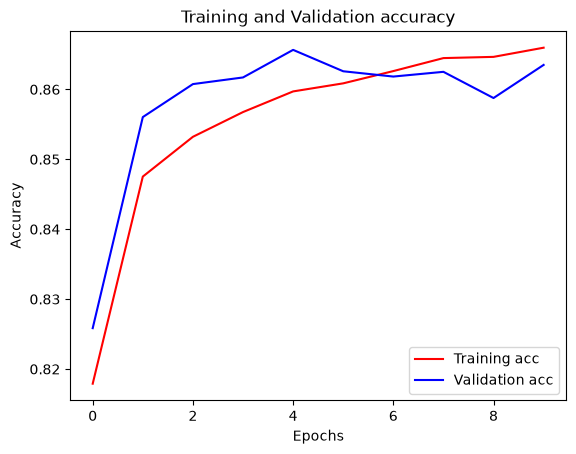

In [28]:
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']

plt.figure()
plt.plot(epochs, acc, 'r', label='Training acc')
plt.plot(epochs, val_acc, 'blue', label='Validation acc')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


* pixel acc
    * 전체 이미지 중 예측과 정답이 같은 픽셀의 비율

* dice 
    * 2*교집합/(예측 크기 + 정답 크기)

* iou
    * 교집합 / 합집합
    * 합집합 = 둘을 더하고 겹친 부분 한 번 빼기

In [29]:
# pixel accuracy, dice score, iou

def evaluate_segmentation(model, test_dataset, num_classes=OUTPUT_CHANNELS, num_batches=None):
    total_correct = 0
    total_pixels = 0
    dice_sum = np.zeros(num_classes)
    iou_sum = np.zeros(num_classes)
    n_images = 0

    for i, (image, true_mask) in enumerate(test_dataset):
        if num_batches is not None and i >= num_batches:
            break
        
        pred_logits = model.predict(image, verbose=0)
        pred_masks = tf.argmax(pred_logits, axis=-1)
        true_masks = tf.squeeze(true_mask, axis=-1)
        true_masks = tf.cast(true_masks, tf.int64)

        # pixel acc: 전체 배치 누적
        correct = tf.reduce_sum(tf.cast(tf.equal(pred_masks, true_masks), tf.float32))
        total_correct += correct.numpy()
        total_pixels += tf.size(true_masks).numpy()

        # dice / iou
        batch_size = image.shape[0]
        for b in range(batch_size):
            pred_mask = pred_masks[b]
            true_mask = true_masks[b]

            # dice
            for c in range(num_classes):
                pred_c = tf.cast(tf.equal(pred_mask, c), tf.float32)
                true_c = tf.cast(tf.equal(true_mask, c), tf.float32)

                intersection = tf.reduce_sum(pred_c * true_c)
                pred_sum = tf.reduce_sum(pred_c)
                true_sum = tf.reduce_sum(true_c)
                union = pred_sum + true_sum - intersection

                dice = (2 * intersection + 1e-7) / (pred_sum + true_sum + 1e-7)
                iou = (intersection + 1e-7) / (union + 1e-7)
                dice_sum[c] += dice.numpy()
                iou_sum[c] += iou.numpy()
            n_images += 1

    pixel_acc = total_correct / total_pixels
    dice_per_class = dice_sum / n_images
    iou_per_class = iou_sum / n_images

    class_names = ['pet', 'border', 'background']
    print(f"Pixel Accuracy: {pixel_acc:.4f}\n")
    print(f"{'class':<15}{'Dice':>10}{'IoU':>10}")

    for c in range(num_classes):
        print(f"{class_names[c]:<12}{dice_per_class[c]:>10.4f}{iou_per_class[c]:>10.4f}")

    print(f"{'mean':<12}{dice_per_class.mean():>10.4f}{iou_per_class.mean():>10.4f}")
    return pixel_acc, dice_per_class, iou_per_class

pixel_acc, dice_scores, iou_scores = evaluate_segmentation(model, test_dataset)

Pixel Accuracy: 0.8655

class                Dice       IoU
pet             0.8521    0.7544
border          0.9134    0.8484
background      0.3363    0.2091
mean            0.7006    0.6040


* 정성 평가
* test sample에 대한 예측

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step


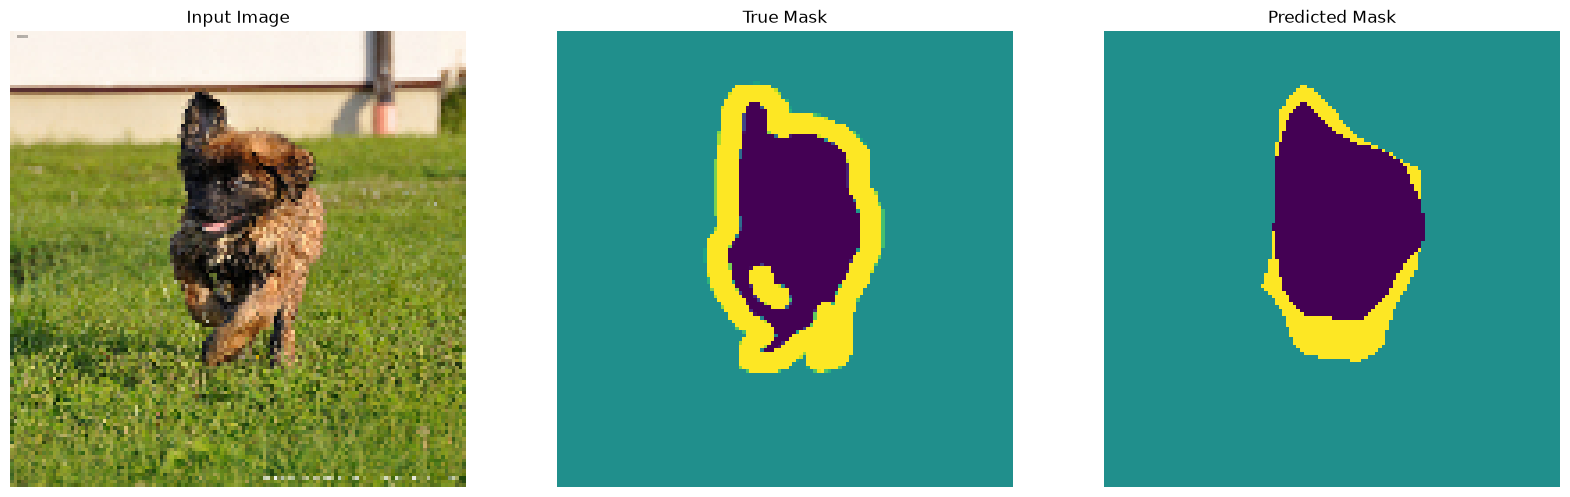

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


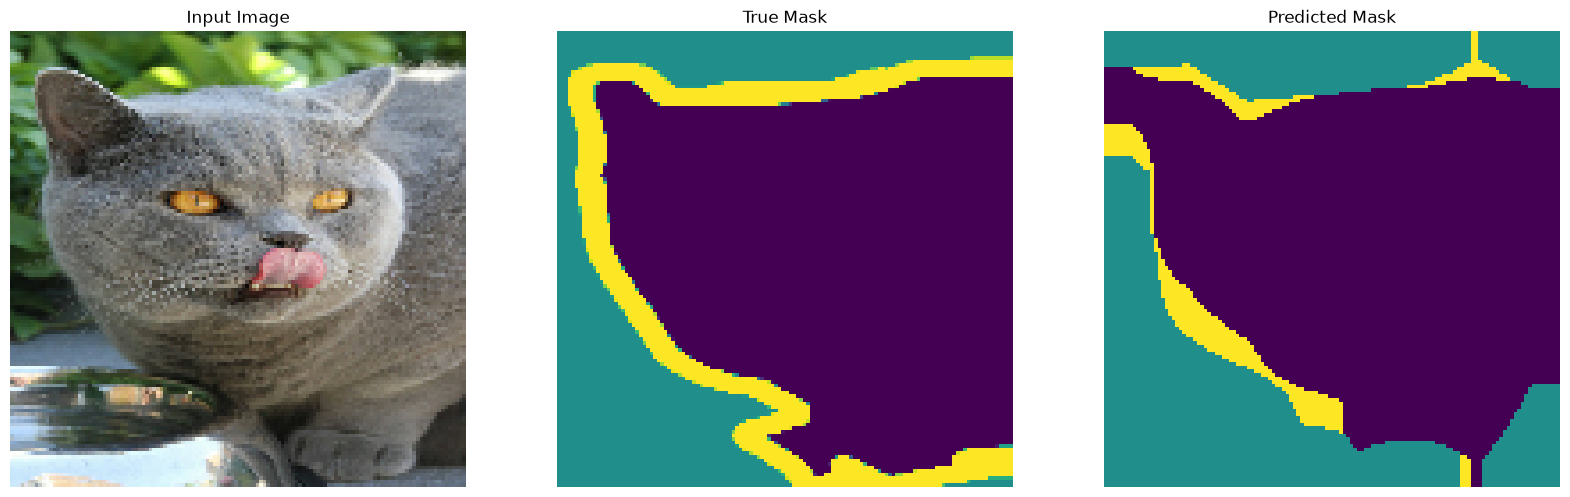

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


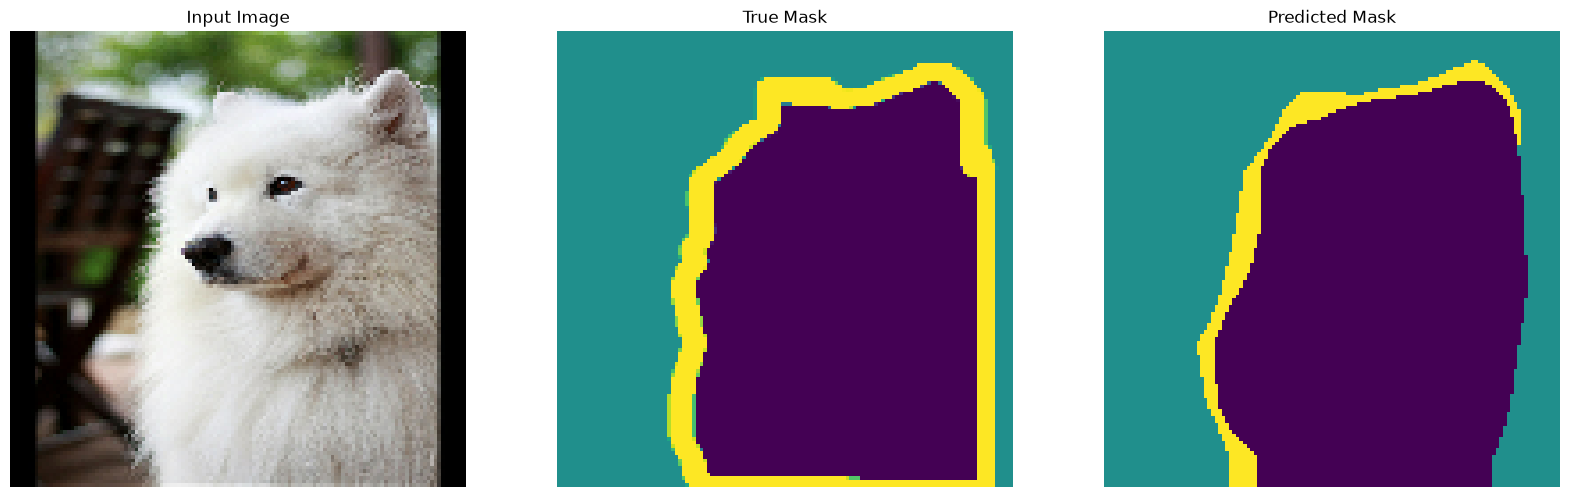

In [ ]:
show_predictions(test_dataset, 3)

꽤 정확하다! 성능이 좋은 듯! 

### Task

* 모델 개선을 위한 태스크

#### task1: Deeper Architecture

* 하... 정말 아무 것도 하고 싶지 안하요. 

#### task2: Use High-Resolution Feature Maps

#### task3: Use Multi-resolution Feature Maps(FCN)

#### task4: Use Convolution Transpose